# Customer Churn Prediction - Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 1. Data Loading and Initial Exploration

In [2]:
df = pd.read_csv('../data/customer_churn.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(0)

print(f"Missing values after conversion:\n{df.isnull().sum()}")

Missing values after conversion:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
print("First 5 rows of dataset:")
df.head()

First 5 rows of dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Basic statistics for numerical columns:")
df.describe()

Basic statistics for numerical columns:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [6]:
print("Data types:")
df.dtypes

Data types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

### Findings: Data Loading and Initial Exploration

- The dataset contains 7,043 customers with 21 features
- `TotalCharges` had 11 missing values that were successfully converted to numeric and filled with 0
- The dataset includes a mix of numerical (tenure, MonthlyCharges, TotalCharges) and categorical features
- `customerID` appears to be a unique identifier and can be excluded from modeling
- `SeniorCitizen` is stored as integer (0/1) but represents a categorical variable

## 2. Target Variable Analysis - Churn Distribution

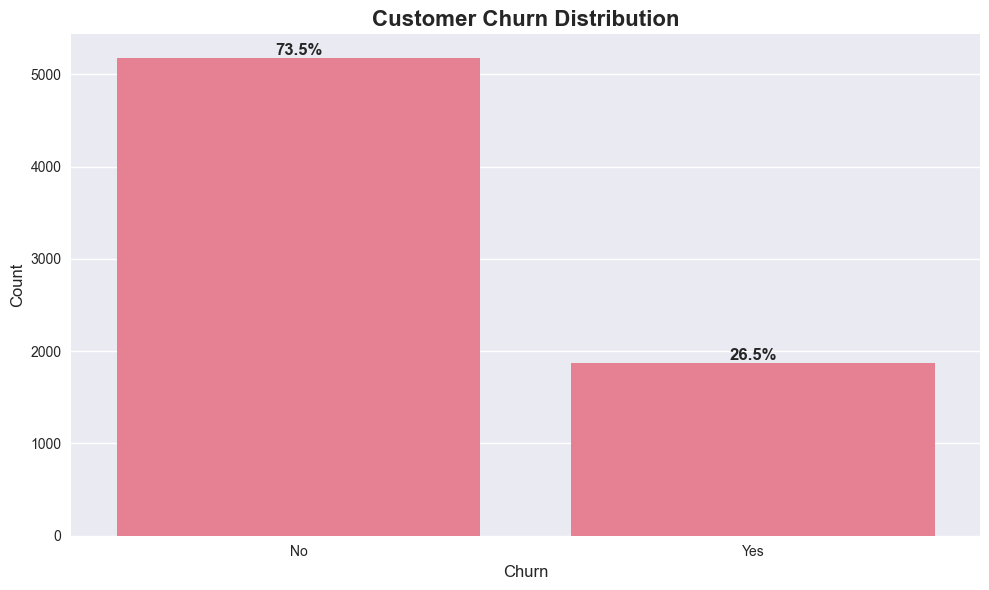

Churn Distribution:
No: 5174 (73.5%)
Yes: 1869 (26.5%)


In [7]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Count', fontsize=12)

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../assets/images/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

churn_counts = df['Churn'].value_counts()
churn_percentages = df['Churn'].value_counts(normalize=True) * 100
print("Churn Distribution:")
for status in churn_counts.index:
    print(f"{status}: {churn_counts[status]} ({churn_percentages[status]:.1f}%)")

### Findings: Churn Distribution

- **Class imbalance detected**: 26.6% of customers have churned (1,869 out of 7,043)
- 73.4% of customers remain active (5,174 out of 7,043)
- This imbalance will need to be addressed during modeling (e.g., using class weights, SMOTE, or appropriate evaluation metrics)
- The churn rate of 26.6% is relatively high, indicating a significant business problem to address

## 3. Numerical Features Analysis

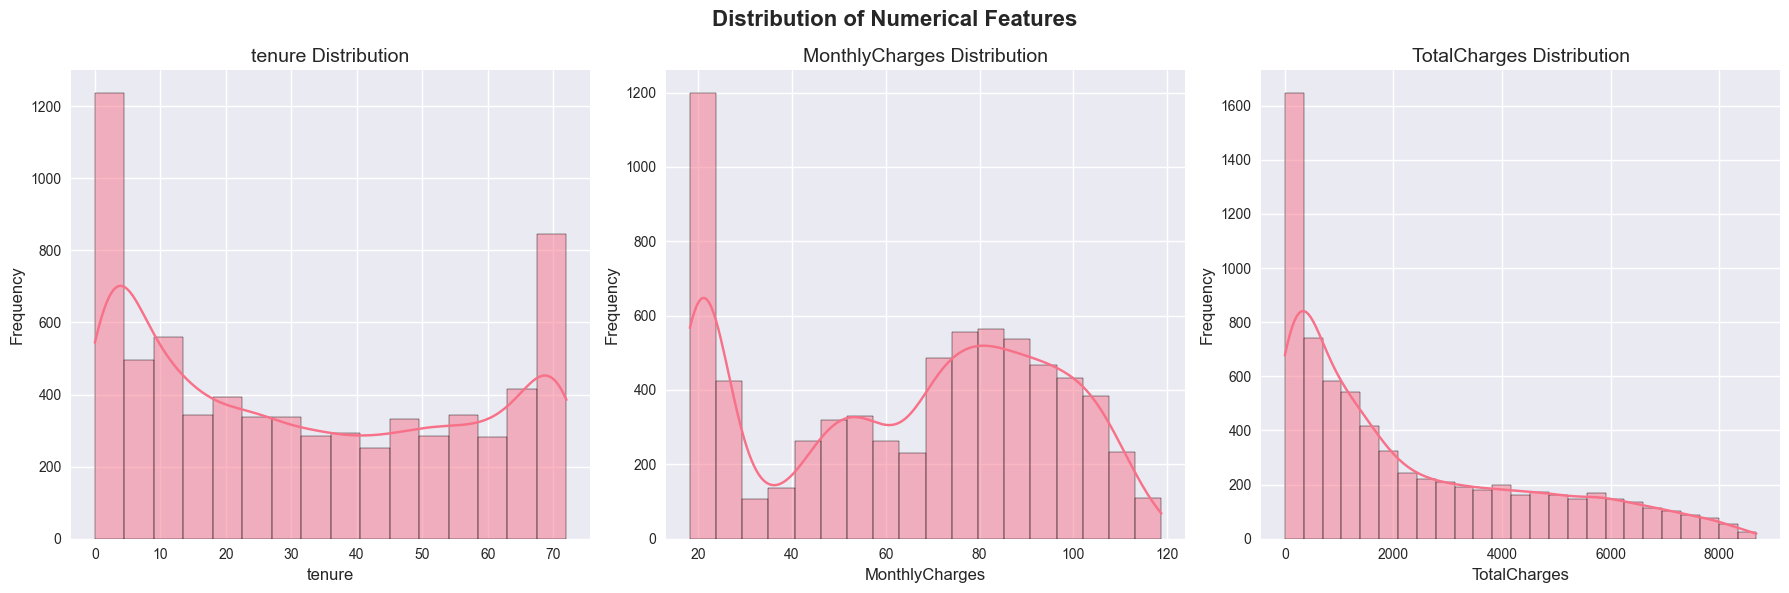

In [8]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

for i, feature in enumerate(numerical_features):
    sns.histplot(data=df, x=feature, kde=True, ax=axes[i])
    axes[i].set_title(f'{feature} Distribution', fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

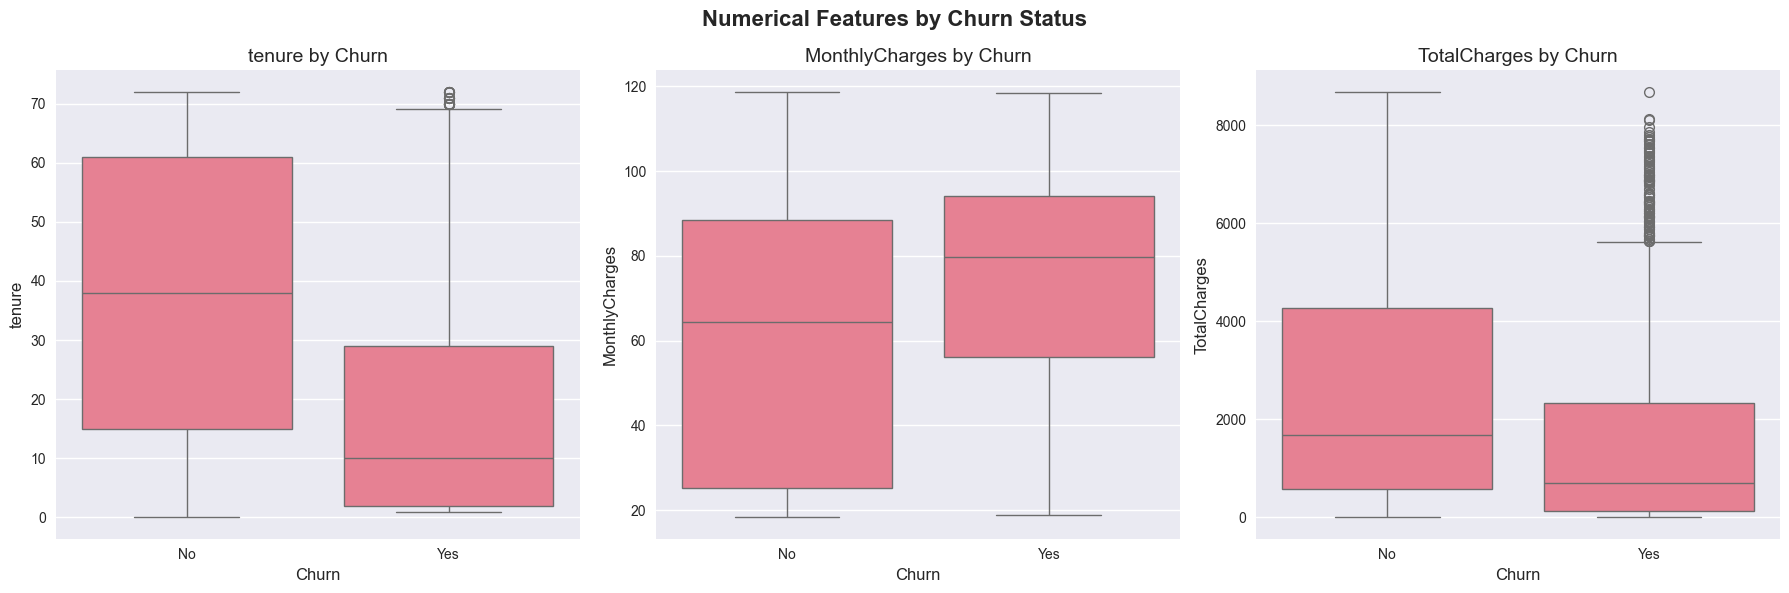

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Numerical Features by Churn Status', fontsize=16, fontweight='bold')

for i, feature in enumerate(numerical_features):
    sns.boxplot(data=df, x='Churn', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature} by Churn', fontsize=14)
    axes[i].set_xlabel('Churn', fontsize=12)
    axes[i].set_ylabel(feature, fontsize=12)

plt.tight_layout()
plt.show()

### Findings: Numerical Features Analysis

**Tenure:**
- Bimodal distribution with peaks at very new customers (0-2 months) and long-term customers (70+ months)
- Customers who churn tend to have significantly lower tenure (median ~10 months vs 38 months for non-churners)
- New customers are much more likely to churn

**MonthlyCharges:**
- Multi-modal distribution suggesting different service tiers
- Customers who churn have higher monthly charges (median ~$80 vs $65 for non-churners)
- Higher monthly charges appear to be a risk factor for churn

**TotalCharges:**
- Right-skewed distribution due to relationship with tenure
- Customers who churn have lower total charges (expected due to shorter tenure)
- This feature is highly correlated with tenure and monthly charges

## 4. Categorical Features Analysis

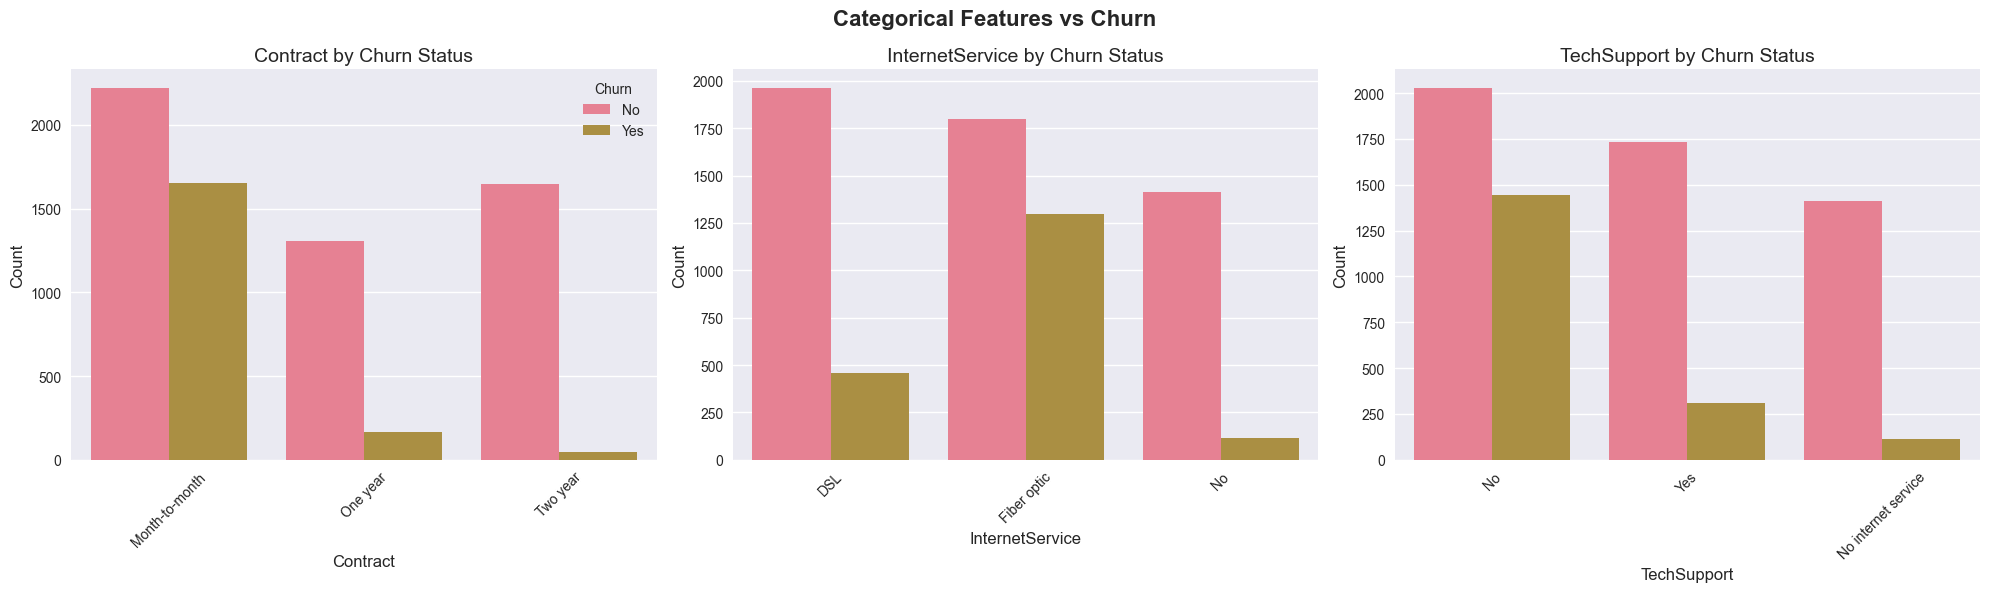

In [10]:
categorical_features = ['Contract', 'InternetService', 'TechSupport']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Categorical Features vs Churn', fontsize=16, fontweight='bold')

for i, feature in enumerate(categorical_features):
    sns.countplot(data=df, x=feature, hue='Churn', ax=axes[i])
    axes[i].set_title(f'{feature} by Churn Status', fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    
    if i == 0:
        axes[i].legend(title='Churn')
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.savefig('../assets/images/churn_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
for feature in categorical_features:
    print(f"\nChurn rate by {feature}:")
    churn_rate = df.groupby(feature)['Churn'].value_counts(normalize=True).unstack()['Yes'] * 100
    print(churn_rate.round(1))


Churn rate by Contract:
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Yes, dtype: float64

Churn rate by InternetService:
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Yes, dtype: float64

Churn rate by TechSupport:
TechSupport
No                     41.6
No internet service     7.4
Yes                    15.2
Name: Yes, dtype: float64


### Findings: Categorical Features Analysis

**Contract Type:**
- Month-to-month contracts have highest churn rate (42.7%)
- One-year contracts show moderate churn (11.3%)
- Two-year contracts have lowest churn rate (2.8%)
- Contract length is a strong predictor of churn

**Internet Service:**
- Fiber optic customers have highest churn rate (41.9%)
- DSL customers have moderate churn (19.0%)
- Customers without internet service have very low churn (7.4%)
- Fiber optic service may have quality or pricing issues

**Tech Support:**
- Customers without tech support have high churn rate (41.6%)
- Customers with tech support have much lower churn (15.2%)
- No internet service customers have very low churn (7.4%)
- Tech support appears to be a significant retention factor

## 5. Correlation Analysis

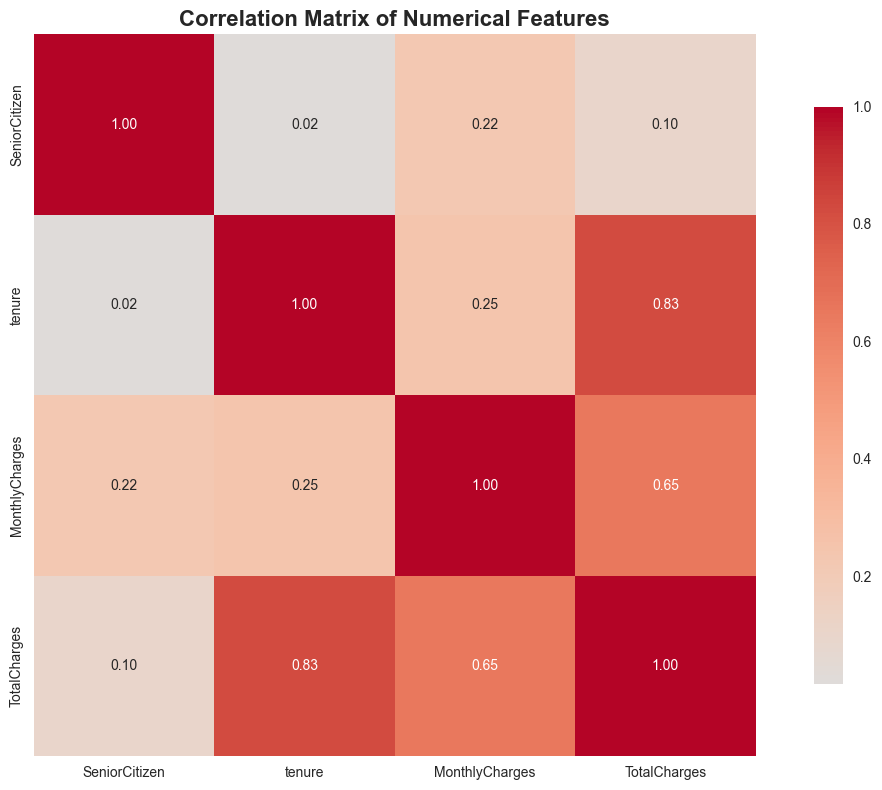

In [12]:
numerical_df = df.select_dtypes(include=[np.number])

correlation_matrix = numerical_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
df_encoded = df.copy()
df_encoded['Churn_binary'] = (df_encoded['Churn'] == 'Yes').astype(int)

correlations_with_churn = numerical_df.corrwith(df_encoded['Churn_binary'])
print("Correlations with Churn:")
print(correlations_with_churn.round(3).sort_values(ascending=False))

Correlations with Churn:
MonthlyCharges    0.193
SeniorCitizen     0.151
TotalCharges     -0.198
tenure           -0.352
dtype: float64


### Findings: Correlation Analysis

**Key Correlations:**
- `TotalCharges` and `tenure` are strongly correlated (0.83) - expected as longer tenure leads to higher total charges
- `TotalCharges` and `MonthlyCharges` are moderately correlated (0.65)
- `tenure` and `MonthlyCharges` have weak positive correlation (0.25)

**Correlations with Churn:**
- `tenure` shows negative correlation with churn (-0.35) - longer tenure reduces churn risk
- `MonthlyCharges` shows positive correlation with churn (0.19) - higher monthly charges increase churn risk
- `TotalCharges` shows negative correlation with churn (-0.20) - likely due to tenure effect

**Implications:**
- High correlation between `tenure` and `TotalCharges` suggests potential multicollinearity
- Consider feature engineering or dimensionality reduction techniques
- `tenure` appears to be the strongest numerical predictor of churn

## 6. Summary and Next Steps

### Key Insights:
1. **Class Imbalance**: 26.6% churn rate requires careful handling in modeling
2. **Strong Predictors**: Contract type, tenure, and tech support are powerful churn indicators
3. **Risk Factors**: Month-to-month contracts, high monthly charges, and no tech support increase churn risk
4. **Retention Factors**: Long-term contracts, tech support, and longer tenure reduce churn

### Recommendations for Modeling:
1. Handle class imbalance using appropriate techniques (SMOTE, class weights)
2. Consider feature engineering for tenure-based segments
3. Address multicollinearity between tenure and TotalCharges
4. Use appropriate evaluation metrics (F1-score, AUC-ROC) due to class imbalance
5. Consider tree-based models that can handle mixed data types well

### Data Quality Issues Resolved:
- Converted `TotalCharges` to numeric and handled missing values
- Identified `SeniorCitizen` as categorical despite numeric storage
- Confirmed data integrity after preprocessing